#  Building a Neural Network from Scratch with PyTorch

---

##  What we'll cover

1. Load & explore the California Housing dataset
2. Preprocess the data (normalize features)
3. Convert data to PyTorch tensors
4. Build a Neural Network using `nn.Module`
5. Define loss function & optimizer
6. Train the model (training loop)
7. Evaluate performance
8. Plot training loss curve

---

##  Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.10.0+cpu
Using device: cpu


---
##  Load & Explore the Data

**California Housing Dataset:**  
Predicts median house value (in $100k) based on 8 features like income, house age, location, etc.

In [2]:
# Load dataset
housing = fetch_california_housing()

X = housing.data
y = housing.target

print("Dataset shape:", X.shape)
print("Target shape: ", y.shape)
print("\nFeature names:")
for i, name in enumerate(housing.feature_names):
    print(f"  [{i}] {name}")
print(f"\nTarget: {housing.target_names}")
print(f"\nSample targets (first 5): {y[:5]}")

Dataset shape: (20640, 8)
Target shape:  (20640,)

Feature names:
  [0] MedInc
  [1] HouseAge
  [2] AveRooms
  [3] AveBedrms
  [4] Population
  [5] AveOccup
  [6] Latitude
  [7] Longitude

Target: ['MedHouseVal']

Sample targets (first 5): [4.526 3.585 3.521 3.413 3.422]


In [3]:
# Quick stats
import pandas as pd

df = pd.DataFrame(X, columns=housing.feature_names)
df['MedHouseVal'] = y
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


---
##  Preprocess the Data

**Why normalize?**  
Neural networks train much better when features are on the same scale.  
We use `StandardScaler` → transforms each feature to mean=0, std=1.

In [4]:
# First split: Train (80%) / Temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Second split: Validation (10%) / Test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set:  {X_test.shape}")
print(f"\nAfter scaling — Train feature mean (should be ~0): {X_train.mean(axis=0).round(3)}")
print(f"After scaling — Train feature std  (should be ~1): {X_train.std(axis=0).round(3)}")

Train set: (16512, 8)
Validation set: (2064, 8)
Test set:  (2064, 8)

After scaling — Train feature mean (should be ~0): [-0. -0.  0. -0. -0. -0.  0. -0.]
After scaling — Train feature std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


---
##  Convert to PyTorch Tensors & Create DataLoaders

PyTorch works with **Tensors** (like NumPy arrays but GPU-compatible and differentiable).  
A **DataLoader** batches our data and shuffles it during training.

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Convert numpy arrays --> PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)  # shape: [N, 1]

X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(device)

X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1).to(device)

# Wrap in TensorDataset
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

# DataLoader
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Tensor dtype: {X_train_t.dtype}")
print(f"\nNumber of batches in train_loader: {len(train_loader)}")
print(f"Batch size: {BATCH_SIZE}")

Tensor dtype: torch.float32

Number of batches in train_loader: 258
Batch size: 64


---
##  Define the Neural Network Architecture

We build our network by subclassing `nn.Module` — the base class for all PyTorch models.

```
Input (8)  →  Hidden1 (64)  →  ReLU  →  Hidden2 (32)  →  ReLU  →  Output (1)
```

**Key concepts:**
- `nn.Linear(in, out)` → a fully connected layer (matrix multiply + bias)
- `nn.ReLU()` → activation function: `max(0, x)` — adds non-linearity
- `forward()` → defines how data flows through the network

In [6]:
class HousingNet(nn.Module):
    def __init__(self, input_dim):
        super(HousingNet, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),   # Layer 1: 8 → 64
            nn.ReLU(),
            nn.Linear(64, 32),          # Layer 2: 64 → 32
            nn.ReLU(),
            nn.Linear(32, 1)            # Output:  32 → 1 (regression)
        )

    def forward(self, x):
        return self.network(x)


# Instantiate the model
input_dim = X_train.shape[1]  # 8 features
model = HousingNet(input_dim).to(device)

print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

HousingNet(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total trainable parameters: 2,689


---
##  Loss Function & Optimizer

- **Loss function** → measures how wrong our predictions are  
  For regression: **MSE** (Mean Squared Error) = average of (predicted - actual)²

- **Optimizer** → updates model weights to reduce loss  
  We use **Adam** — an adaptive optimizer that works great out of the box

- **Learning rate** → controls how big each weight update step is

In [7]:
LEARNING_RATE = 0.001

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Loss function: {criterion}")
print(f"Optimizer:     {optimizer.__class__.__name__}")
print(f"Learning rate: {LEARNING_RATE}")

Loss function: MSELoss()
Optimizer:     Adam
Learning rate: 0.001


---
##  Training Loop

The training loop repeats for N **epochs** (full passes over the training data).  
Each step:

1. **Forward pass** → compute predictions
2. **Compute loss** → compare predictions to labels
3. **Backward pass** → compute gradients (autograd!)
4. **Update weights** → optimizer steps in the gradient direction
5. **Zero gradients** → reset before next batch (important!)

In [8]:
NUM_EPOCHS = 50

train_losses = []
val_losses   = []

for epoch in range(1, NUM_EPOCHS + 1):

    # --- Training phase ---
    model.train()  # Set model to training mode
    epoch_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        # 1. Forward pass
        predictions = model(X_batch)

        # 2. Compute loss
        loss = criterion(predictions, y_batch)

        # 3. Zero gradients (must do before backward!)
        optimizer.zero_grad()

        # 4. Backward pass (compute gradients)
        loss.backward()

        # 5. Update weights
        optimizer.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation phase ---
    model.eval()  # Set model to eval mode
    epoch_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    # Print every 10 epochs
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch [{epoch:>3}/{NUM_EPOCHS}]  "
              f"Train Loss: {avg_train_loss:.4f}  "
              f"Val Loss: {avg_val_loss:.4f}")

Epoch [  1/50]  Train Loss: 1.5014  Val Loss: 0.6399
Epoch [ 10/50]  Train Loss: 0.3203  Val Loss: 0.3345
Epoch [ 20/50]  Train Loss: 0.2894  Val Loss: 0.3150
Epoch [ 30/50]  Train Loss: 0.2750  Val Loss: 0.3011
Epoch [ 40/50]  Train Loss: 0.2675  Val Loss: 0.2910
Epoch [ 50/50]  Train Loss: 0.2594  Val Loss: 0.2869


---
##  Plot Training & Validation Loss

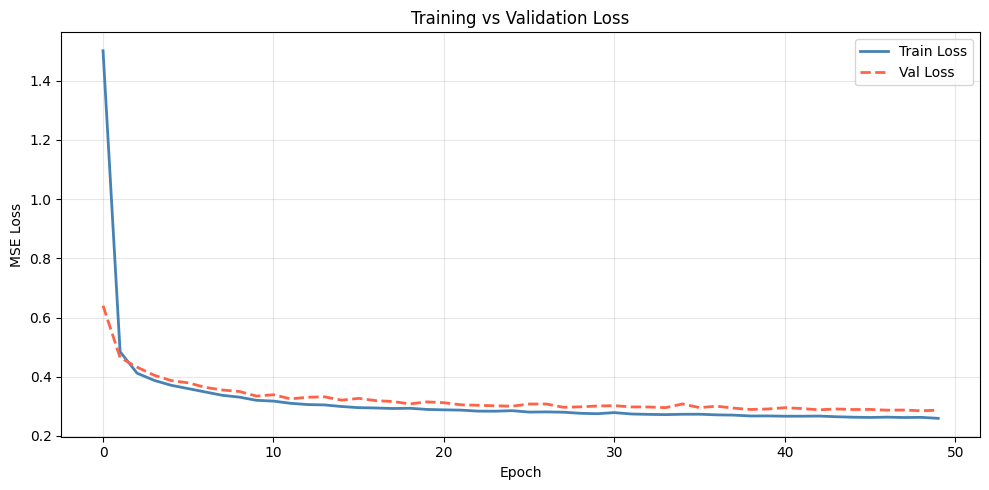

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
plt.plot(val_losses,   label='Val Loss',   color='tomato',    linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
##  Evaluate the Model

We'll compute two metrics:
- **MSE** (Mean Squared Error) — same as training loss
- **RMSE** (Root MSE) — same unit as target (in $100k)
- **MAE** (Mean Absolute Error) — average absolute error

In [10]:
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch)
        all_preds.append(preds.cpu())
        all_labels.append(y_batch.cpu())

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

mse  = np.mean((all_preds - all_labels) ** 2)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(all_preds - all_labels))

print("📊 Test Set Evaluation")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}  (in units of $100k)")
print(f"  MAE  : {mae:.4f}  (in units of $100k)")
print(f"\n  → Average prediction error: ~${mae * 100_000:,.0f}")

📊 Test Set Evaluation
  MSE  : 0.2826
  RMSE : 0.5316  (in units of $100k)
  MAE  : 0.3632  (in units of $100k)

  → Average prediction error: ~$36,322


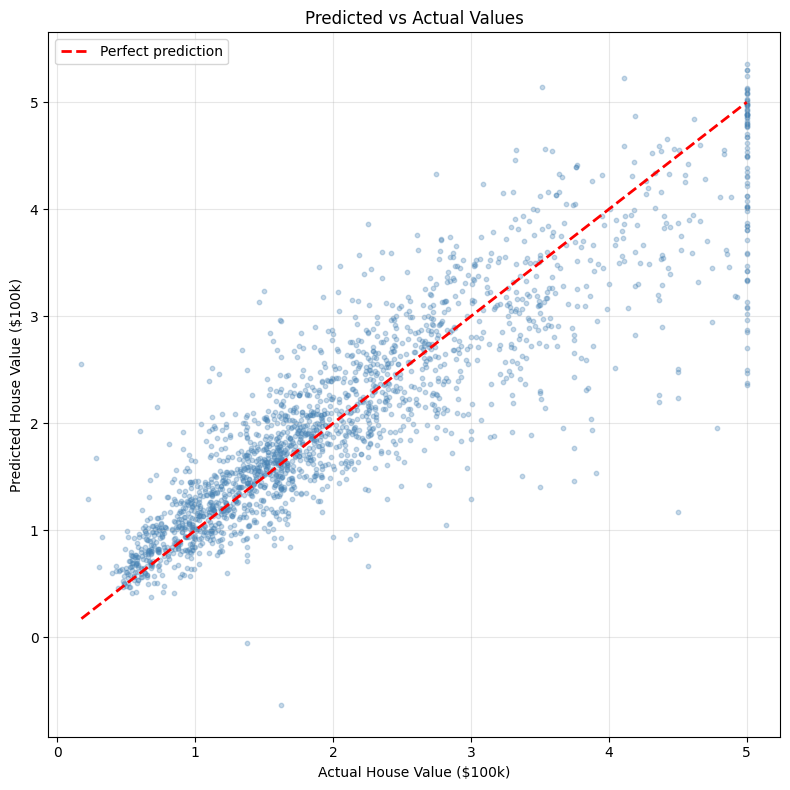

In [11]:
# Scatter plot: Predicted vs Actual
plt.figure(figsize=(8, 8))
plt.scatter(all_labels, all_preds, alpha=0.3, s=10, color='steelblue')
plt.plot([all_labels.min(), all_labels.max()],
         [all_labels.min(), all_labels.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual House Value ($100k)')
plt.ylabel('Predicted House Value ($100k)')
plt.title('Predicted vs Actual Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
##  Making a Single Prediction

In [12]:
# Pick one sample from test set
sample_idx = 0
sample_input  = X_test_t[sample_idx].unsqueeze(0)  # shape: [1, 8]
actual_value  = y_test[sample_idx]

model.eval()
with torch.no_grad():
    predicted_value = model(sample_input).item()

print(f"Actual value:    ${actual_value * 100_000:,.0f}")
print(f"Predicted value: ${predicted_value * 100_000:,.0f}")
print(f"Difference:      ${abs(predicted_value - actual_value) * 100_000:,.0f}")

Actual value:    $238,500
Predicted value: $312,711
Difference:      $74,211


---
##  Save & Load the Model

In [ ]:
# Save model weights
torch.save(model.state_dict(), 'housing_net.pth')
print(" Model saved to housing_net.pth")

# Load it back
loaded_model = HousingNet(input_dim).to(device)
loaded_model.load_state_dict(torch.load('housing_net.pth', map_location=device))
loaded_model.eval()
print(" Model loaded successfully")

✅ Model saved to housing_net.pth
✅ Model loaded successfully


##  Model Architecture Notes
The model uses a relatively simple fully connected neural network:

- Input → 64 → 32 → 1  
- Activation: ReLU  

This architecture was intentionally kept simple to establish a **baseline model** before experimenting with more complex architectures.

 Design Goals:
- Reduce risk of overfitting  
- Evaluate baseline performance with minimal complexity  

---

##  Training Behavior

### Training Progress:
- Train Loss decreased from **1.50 → 0.26**
- Validation Loss decreased from **0.64 → 0.29**

###  Observations:
- Both training and validation losses decrease steadily  
- The gap between them is relatively small  

 Interpretation:
-  No significant overfitting  
-  Model is learning useful patterns  
-  Slight underfitting due to limited model capacity  

---

##  Convergence Analysis
- The model shows **smooth and stable convergence**
- Loss reduction slows down after ~30 epochs  

 This suggests:
- The model is approaching its learning limit  
- Additional epochs may yield only minor improvements  

---

##  Final Evaluation (Test Set)

- **MSE**  : 0.2826  
- **RMSE** : 0.5316 (~$53,160)  
- **MAE**  : 0.3632 (~$36,322)  

 Interpretation:
- On average, predictions deviate by about **$36k**
- Presence of larger errors (outliers) is reflected in higher RMSE  

---

##  Error Analysis Insight
- Some individual predictions show significantly higher error (e.g., ~$74k)
- These cases likely correspond to:
  - Outliers  
  - Complex or rare feature combinations  

 The model captures general trends well but struggles with extreme cases  

---

##  Conclusion
### Current Model:
-  Good baseline performance  
-  Stable training behavior  
-  Limited capacity → slight underfitting  

### Potential Improvements:
- Increase model complexity (more layers / neurons)  
- Apply feature engineering  
- Transform target variable (e.g., log scaling)  
- Experiment with more advanced models  

---
###  Next Steps to Explore

- [ ] **Add Dropout** → `nn.Dropout(0.2)` to reduce overfitting
- [ ] **Add Batch Normalization** → `nn.BatchNorm1d` for faster training
- [ ] **Try deeper architectures** → more layers, more neurons
- [ ] **Learning rate scheduler** → reduce lr when val loss plateaus
- [ ] **Early stopping** → stop training when val loss stops improving
- [ ] **Try classification** → swap dataset + loss to `CrossEntropyLoss`

---
##  Key Takeaway
This model provides a solid baseline and demonstrates that even a simple neural network can capture meaningful patterns, but further improvements are needed to reduce prediction error and handle outliers more effectively.